# Noise and signal correlation in simultaneously recorded selective pairs

Every pair here is **two FDR-selective units recorded simultaneously in the same
region**. Two things are measured on those same pairs, and the point of putting
them together is that neither is interpretable alone.

| | noise correlation | signal correlation |
|---|---|---|
| computed on | per-fixation 1 ms spike trains | condition-averaged rate timelines |
| asks | do they fire together on the **same** fixation | do their **mean responses** share a shape |
| null | circular shift within fixation | unit of the same region, different session |

Averaging over fixations removes trial-by-trial covariation entirely. That is
the whole difference between the two rows of the schematic, and it is why a pair
can have either without the other.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.analysis import fixation_signal_correlation as sc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_correlation_overview as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

CFG_PATH = str(repo_root / "configs" / "dataset.yaml")
cfg = load_config(CFG_PATH)
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "overview"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairOverviewPlotSettings(output_dir=FIGURE_DIR)
SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
print("figures ->", FIGURE_DIR)

figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/overview


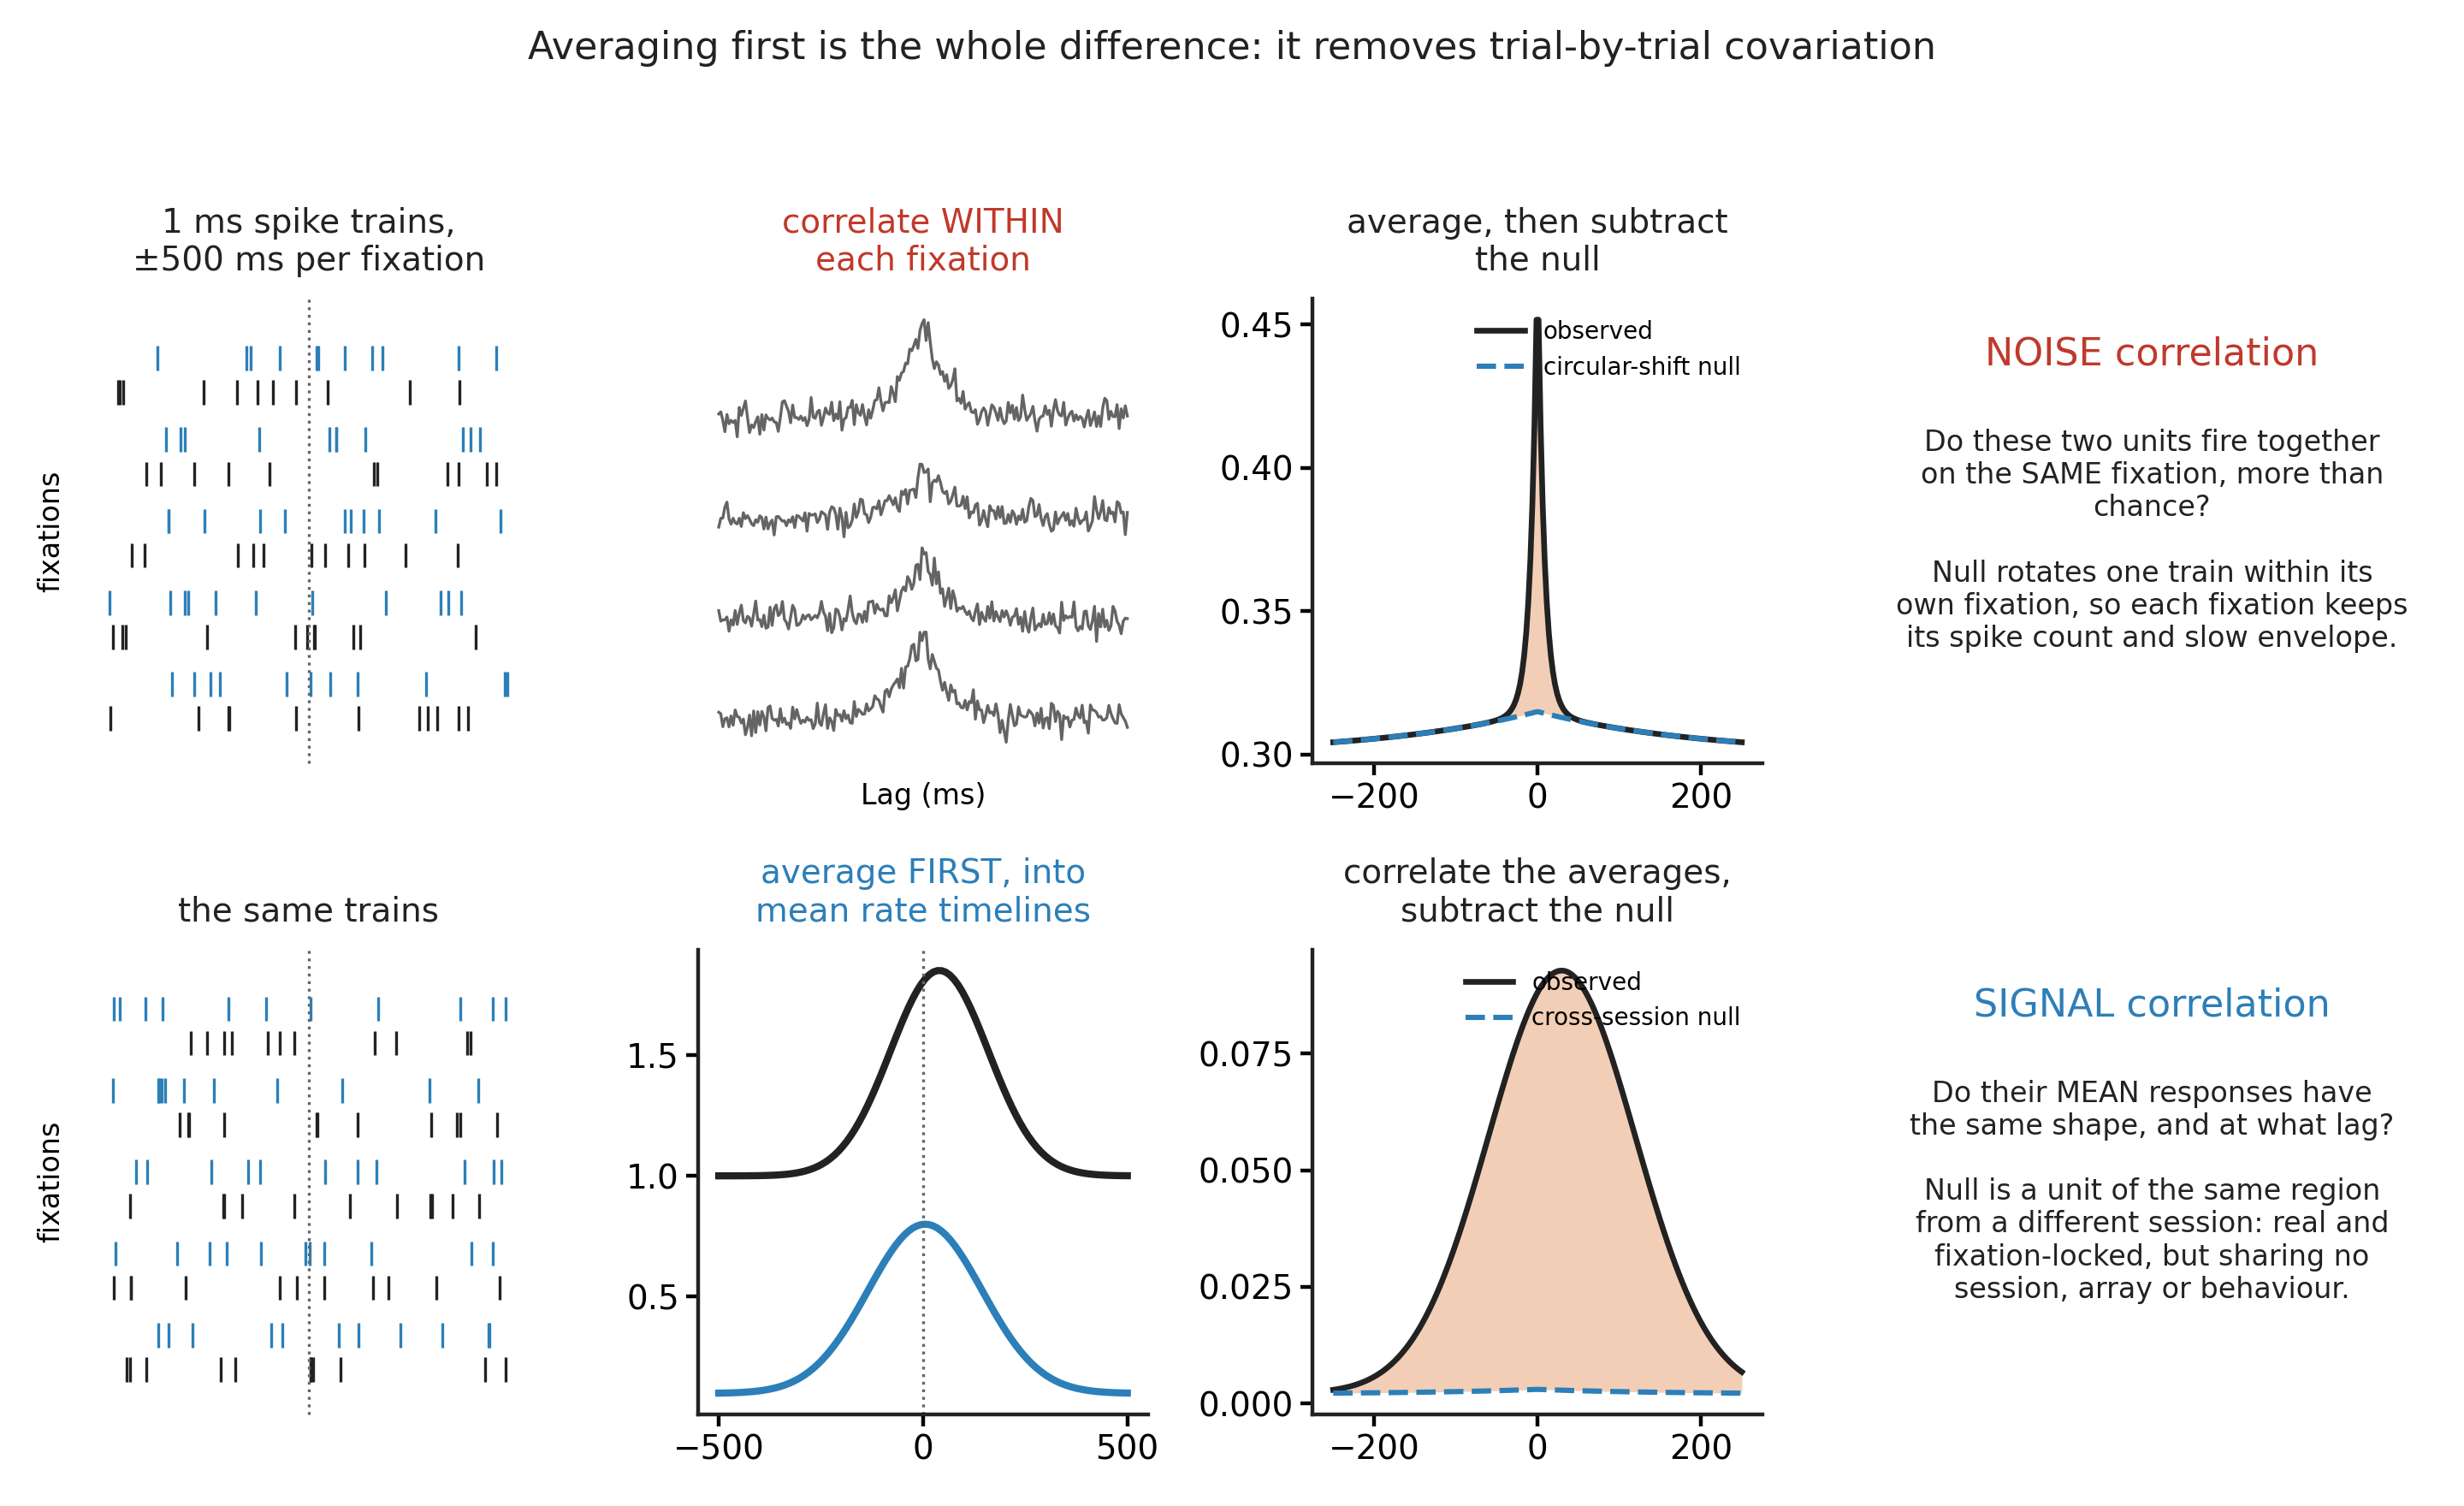

In [2]:
fig, paths = viz.plot_method_schematic(figs)
display(Image(filename=str(paths["png"])))

## 1. What is in the analysis

In [3]:
# --- noise correlation: per-fixation spike trains, circular-shift null -------
noise = psc.load_pair_coordination(CFG_PATH)[0]
noise, dropped = psc.drop_zero_lag_artifact_dates(noise)
noise = noise.loc[noise["both_selective"] & noise["same_region"]].copy()
noise_traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")
print(f"noise: {len(noise):,} pair-conditions, both units FDR-selective, "
      f"within region   (artifact dates removed: {dropped})")

# --- signal correlation: condition-averaged timelines, cross-session null ----
signal_settings = sc.SignalCorrelationSettings(cfg_path=CFG_PATH)
units, timeline = sc.load_condition_timelines(signal_settings)
signal, signal_lags = sc.build_pair_correlations(units, timeline, signal_settings)
signal_within = signal.loc[signal["scope"] == "within_region"]
print(f"signal: {len(signal_within):,} within-region pairs from {len(units)} selective units")

display(
    noise.groupby("region_pair", observed=True)
    .agg(noise_pairs=("pair_key", "size"))
    .join(
        signal_within.groupby("region_pair", observed=True)
        .size().rename("signal_pairs").to_frame()
    )
)

noise: 66,864 pair-conditions, both units FDR-selective, within region   (artifact dates removed: ['09272018', '09292018'])


signal: 3,005 within-region pairs from 574 selective units


,noise_pairs,signal_pairs
region_pair,,
accg,6949,356
bla,39015,1786
dmpfc,7054,320
ofc,13846,543


# Noise correlation

## 2. It sits above the null

Interactive-face fixations, per region: the observed cross-correlation against
the circular-shift null. The gap is the coordination.

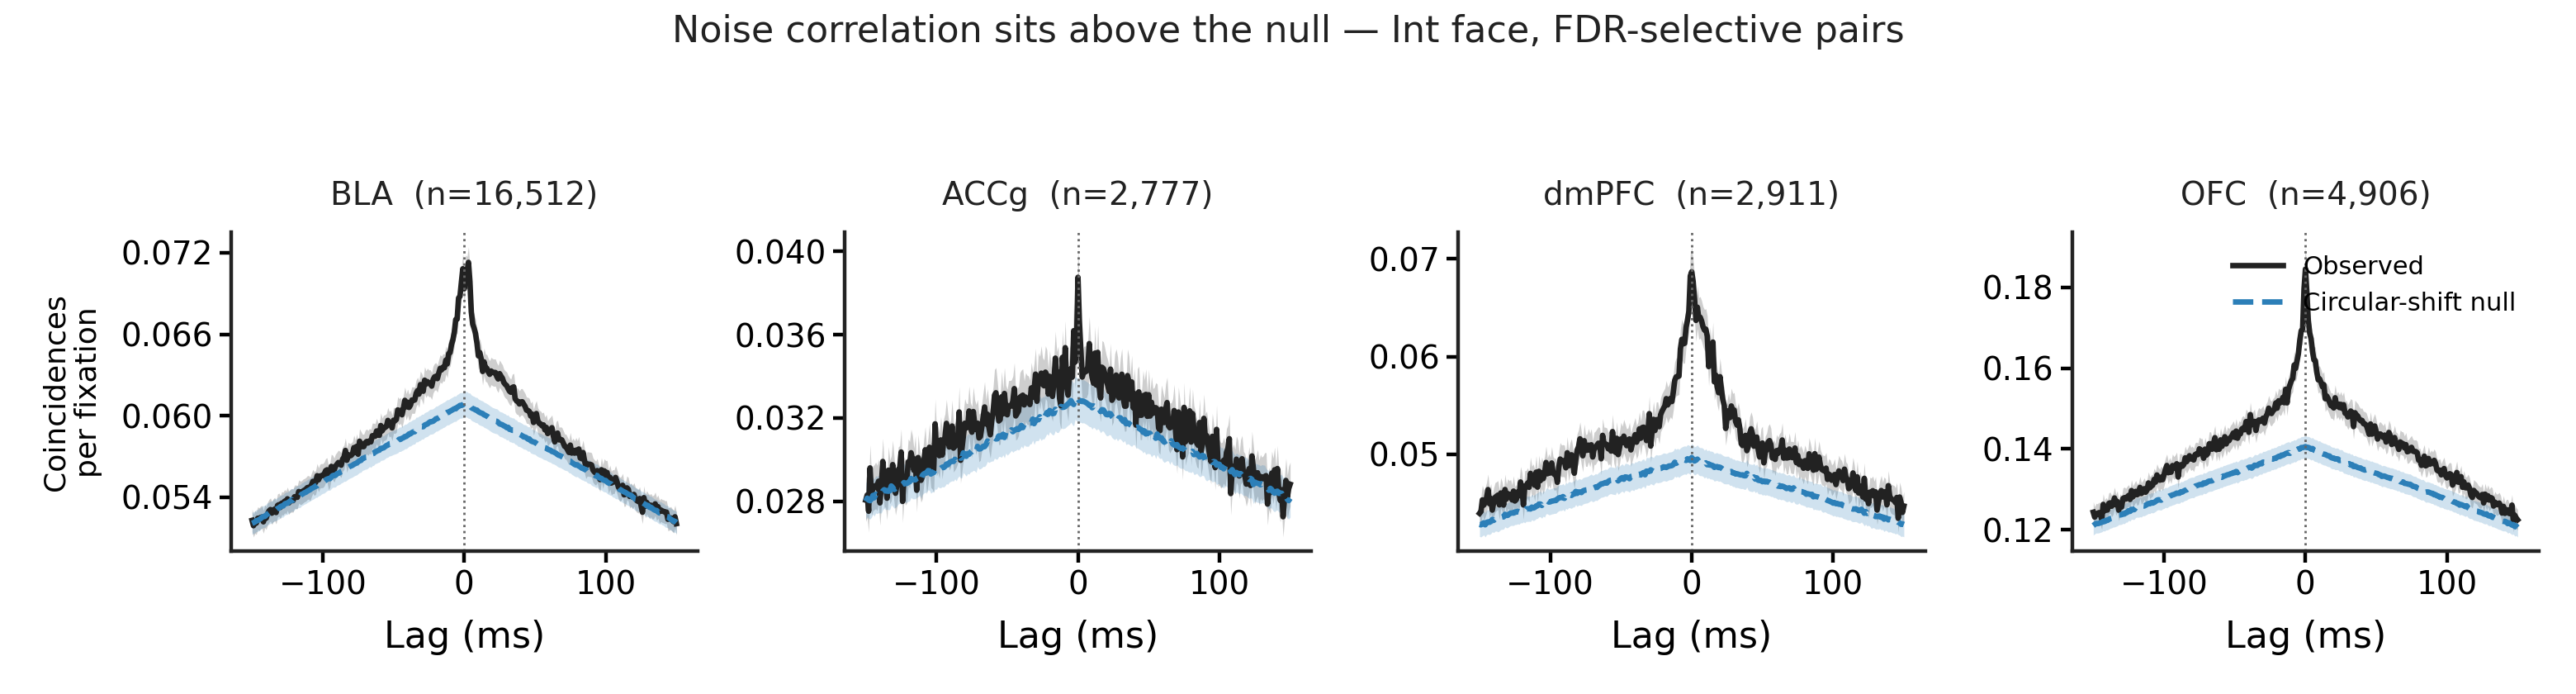

In [4]:
fig, paths = viz.plot_noise_above_null(noise_traces, figs, condition="face_interactive")
display(Image(filename=str(paths["png"])))

## 3. But the fixation types do not differ

The same quantity, null-corrected, for all three conditions. Trial-count matched,
because interactive-face fixations outnumber the others roughly six to one.

Read the **effect sizes**, not the asterisks. With thousands of pairs per region
almost any difference reaches significance; rank-biserial is the number that
says whether it is a difference worth reporting.

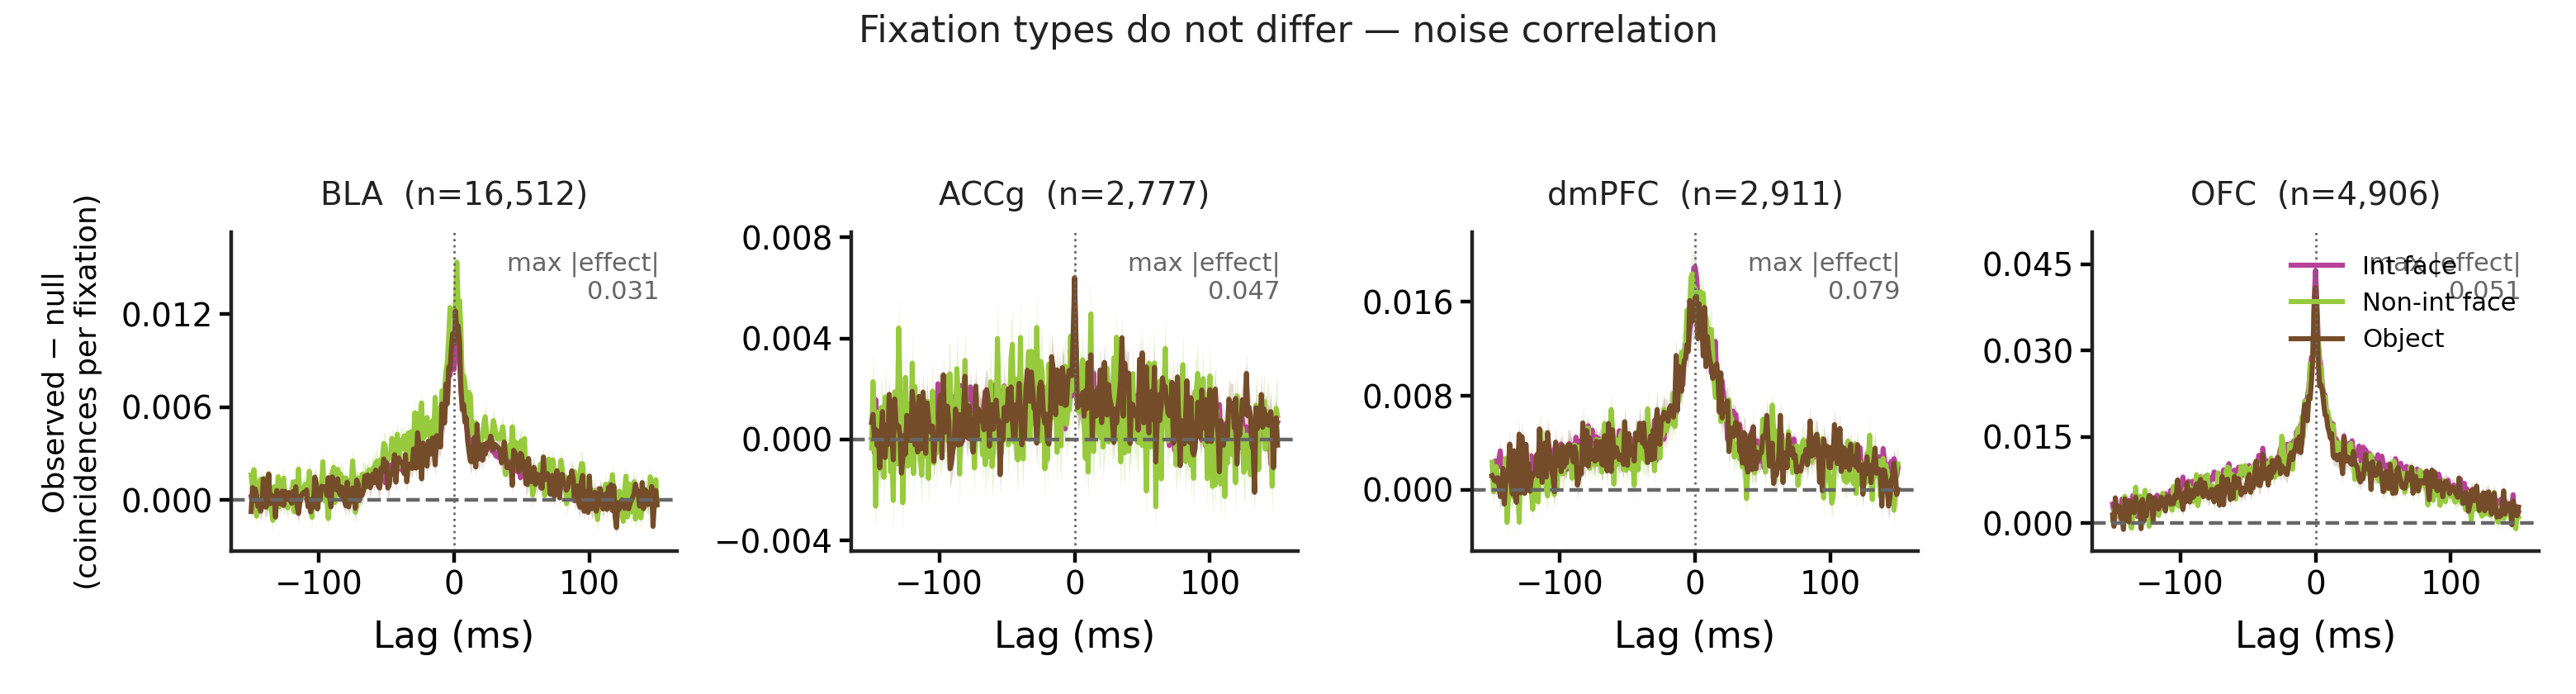

,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg,face_interactive,face_non_interactive,1796,0.00250,0.04677,0.03282,True
1,accg,face_interactive,object,1990,-0.00230,-0.00654,0.92649,False
2,accg,face_non_interactive,object,1723,-0.00516,-0.04701,0.00754,True
3,bla,face_interactive,face_non_interactive,9391,0.00213,0.03047,0.00127,True
4,bla,face_interactive,object,10012,0.00074,-0.00090,0.03559,True
5,bla,face_non_interactive,object,8479,-0.00157,-0.03067,0.20992,False
6,dmpfc,face_interactive,face_non_interactive,1906,0.00525,0.06723,0.00047,True
7,dmpfc,face_interactive,object,1813,0.00845,0.07896,0.00005,True
8,dmpfc,face_non_interactive,object,1609,0.00237,-0.01619,0.82461,False
9,ofc,face_interactive,face_non_interactive,4288,0.00585,0.05084,0.00269,True


largest |effect size| across all contrasts: 0.079
contrasts reaching significance: 8 of 12


In [5]:
noise_contrasts = psc.compare_conditions(
    noise, metric="circular_shift_peak_pm2ms_matched", group_columns=("region_pair",)
)
fig, paths = viz.plot_excess_by_condition(
    noise_traces, figs, contrasts=noise_contrasts,
    ylabel="Observed − null\n(coincidences per fixation)",
    title="Fixation types do not differ — noise correlation",
    stem="fig03_noise_excess",
)
display(Image(filename=str(paths["png"])))

display(
    noise_contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs",
            "mean_difference", "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(5)
)
print(f"largest |effect size| across all contrasts: "
      f"{noise_contrasts['effect_size_rank_biserial'].abs().max():.3f}")
print(f"contrasts reaching significance: {int(noise_contrasts['significant'].sum())} "
      f"of {len(noise_contrasts)}")

# Signal correlation

## 4. Null-corrected correlation across lags

The cross-session null is subtracted, so zero means "resembles a same-region unit
from another session no more than chance".

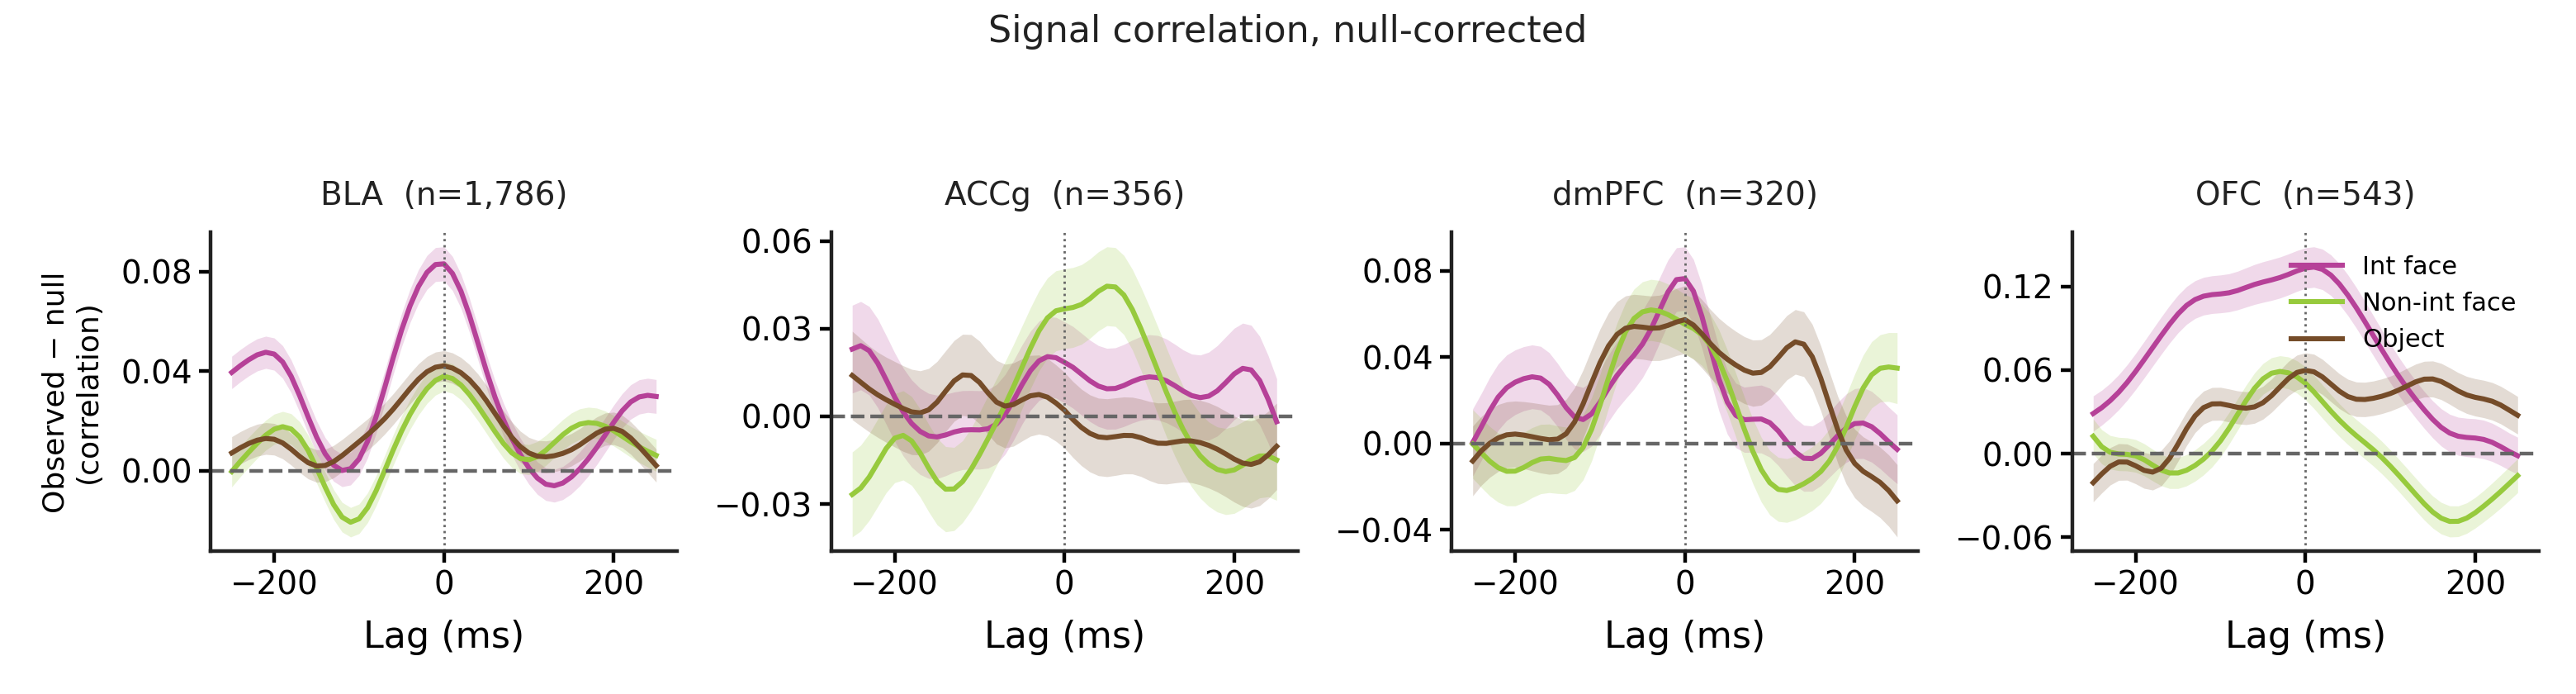

In [6]:
signal_traces = {
    "lags_ms": signal_lags,
    "traces": sc.build_group_traces(signal, signal_settings),
}
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, max_lag_ms=250.0,
    ylabel="Observed − null\n(correlation)",
    title="Signal correlation, null-corrected",
    stem="fig04_signal_excess",
)
display(Image(filename=str(paths["png"])))

## 5. Summarised away from zero lag

Zero lag is one bin of fifty and a poor summary: two units whose responses share
a shape but differ in latency correlate strongly at a non-zero lag and weakly at
zero. Three measures instead —

- **peak**: the maximum over ±100 ms, i.e. similarity at best alignment
- **mean +20 to +200 ms** and **mean −20 to −200 ms**: whether that alignment is symmetric

Two caveats on reading these. The peak is a maximum over many noisy lags and is
biased upward in level — but identically for every condition, so comparisons
hold even though the absolute value does not. And within a region the ordering
of the two units in a pair is arbitrary, so the **sign** of a lead/lag difference
carries no meaning; the two bands are expected to be similar and it is a
departure that would be notable.

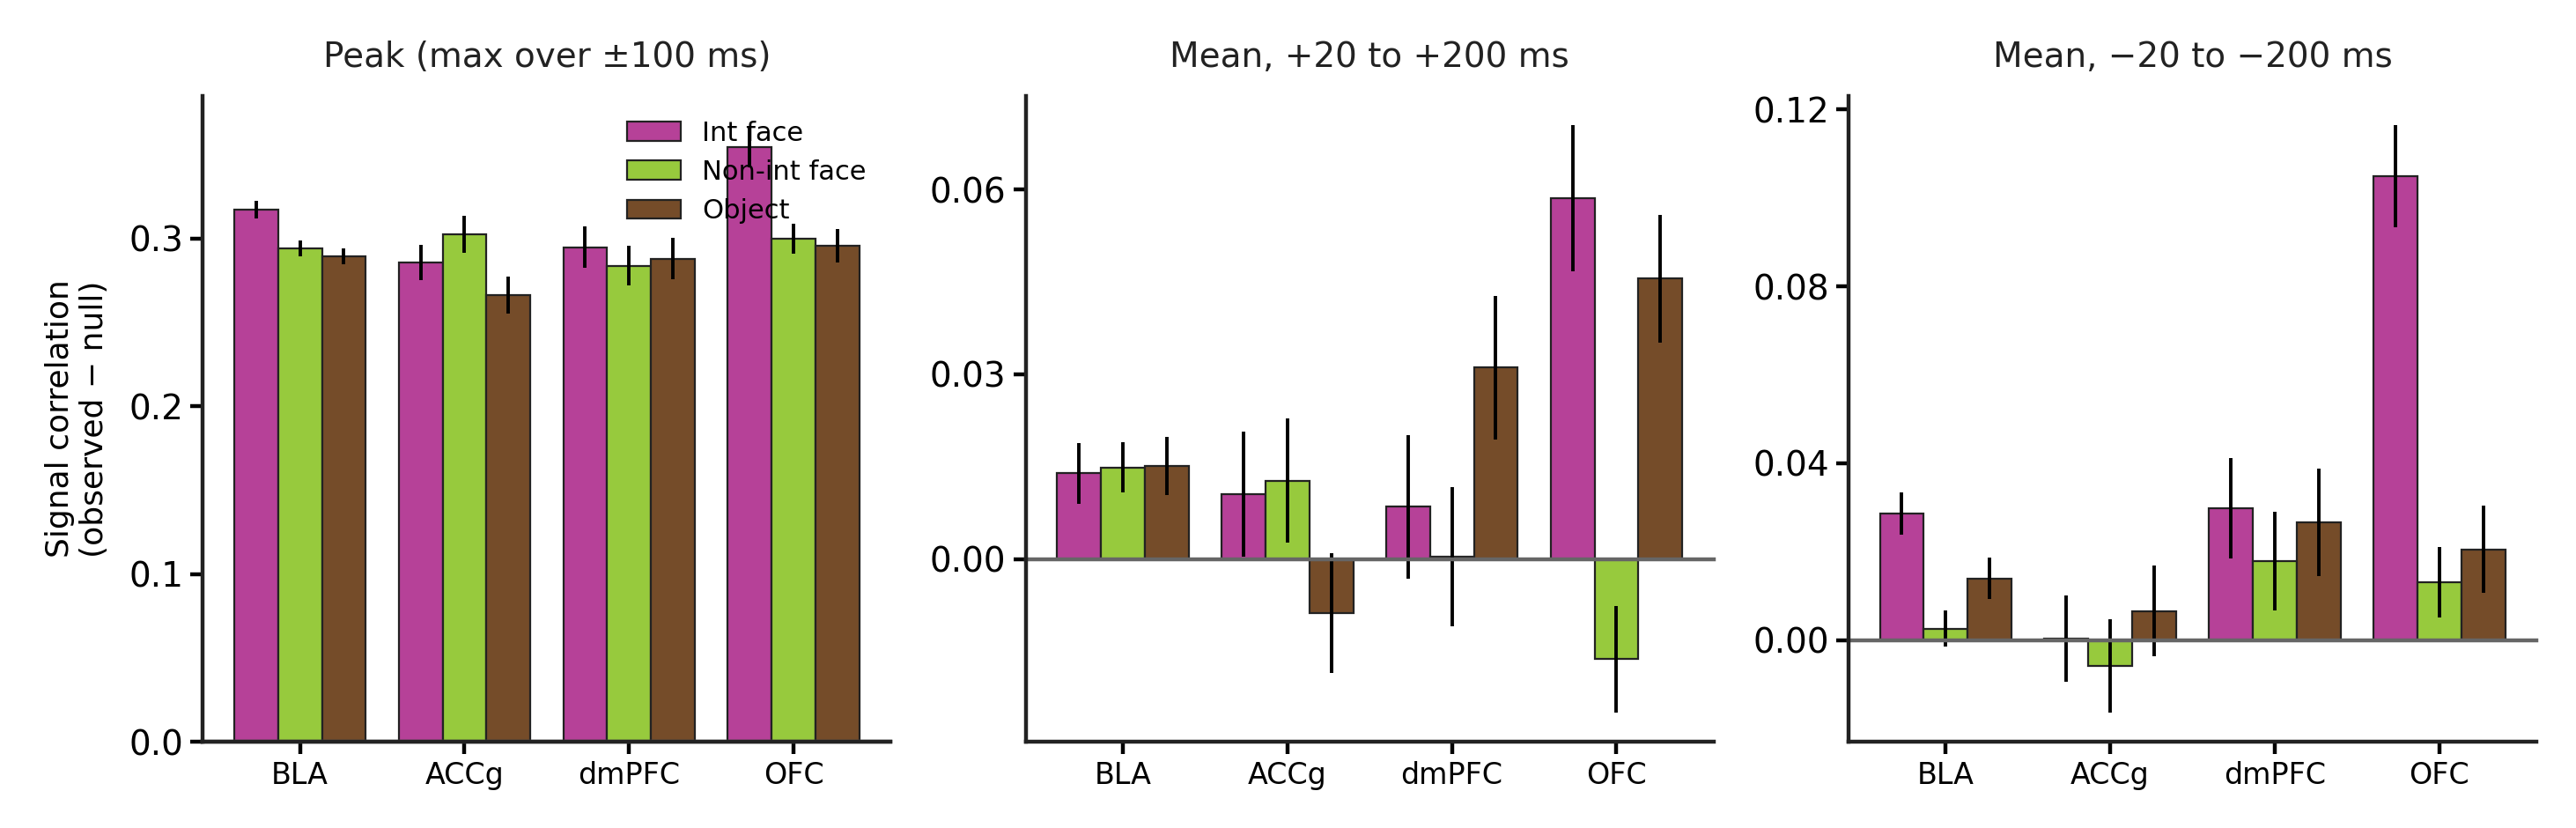

**peak_excess**

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.2858,0.3025,0.2661
bla,0.3170,0.2940,0.2895
dmpfc,0.2946,0.2836,0.2880
ofc,0.3544,0.2998,0.2956


**positive_lag_excess**

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.0106,0.0127,-0.0087
bla,0.0139,0.0149,0.0152
dmpfc,0.0085,0.0004,0.0311
ofc,0.0586,-0.0162,0.0455


**negative_lag_excess**

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.0003,-0.0058,0.0065
bla,0.0287,0.0026,0.0140
dmpfc,0.0299,0.0178,0.0267
ofc,0.1049,0.0131,0.0206


,measure,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,significant
0,peak_excess,accg,face_interactive,face_non_interactive,356,-0.0167,-0.0562,False
1,peak_excess,accg,face_interactive,object,356,0.0196,0.0562,False
2,peak_excess,accg,face_non_interactive,object,356,0.0363,0.1404,True
3,peak_excess,bla,face_interactive,face_non_interactive,1786,0.0230,0.0638,True
4,peak_excess,bla,face_interactive,object,1786,0.0275,0.1008,True
5,peak_excess,bla,face_non_interactive,object,1786,0.0045,0.0168,False
6,peak_excess,dmpfc,face_interactive,face_non_interactive,320,0.0110,0.0062,False
7,peak_excess,dmpfc,face_interactive,object,320,0.0066,0.0250,False
8,peak_excess,dmpfc,face_non_interactive,object,320,-0.0044,0.0562,False
9,peak_excess,ofc,face_interactive,face_non_interactive,543,0.0546,0.1786,True


In [7]:
lag_summary = sc.summarize_lag_measures(signal, signal_settings)
fig, paths = viz.plot_lag_band_summary(lag_summary, figs)
display(Image(filename=str(paths["png"])))

for measure in ("peak_excess", "positive_lag_excess", "negative_lag_excess"):
    display(Markdown(f"**{measure}**"))
    display(
        lag_summary.loc[lag_summary["measure"] == measure]
        .pivot_table(index="region_pair", columns="condition", values="mean").round(4)
    )

lag_contrasts = sc.compare_lag_measures(signal, signal_settings)
display(
    lag_contrasts.loc[
        lag_contrasts["measure"].isin(
            ["peak_excess", "positive_lag_excess", "negative_lag_excess"]
        ),
        ["measure", "region_pair", "condition_a", "condition_b", "n_pairs",
         "mean_difference", "effect_size_rank_biserial", "significant"],
    ].round(4)
)

# Putting them together

## 6. Do the two measures track each other?

Pairs that share a response profile need not covary trial to trial, and vice
versa. Matching each pair to both of its measurements answers it directly.

/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/analysis/fixation_signal_correlation.py:670: PerformanceWarning: indexing past lexsort depth may impact performance.
  if key not in lookup.index:
/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/analysis/fixation_signal_correlation.py:672: PerformanceWarning: indexing past lexsort depth may impact performance.
  value = lookup.loc[key]


pairs with both measurements: 9,301


,scope,region_pair,condition,n_pairs,spearman_rho,p_value
0,cross_region,accg-bla,face_interactive,251,-0.0237,0.7090
1,cross_region,accg-bla,face_non_interactive,249,-0.0545,0.3921
2,cross_region,accg-bla,object,251,-0.0869,0.1700
3,within_region,accg,face_interactive,354,-0.0007,0.9888
4,within_region,accg,face_non_interactive,325,0.0008,0.9883
5,within_region,accg,object,351,0.1279,0.0165
6,within_region,bla,face_interactive,1714,0.1237,0.0000
7,within_region,bla,face_non_interactive,1656,0.0199,0.4178
8,within_region,bla,object,1617,0.0571,0.0217
9,within_region,dmpfc,face_interactive,320,0.0969,0.0834


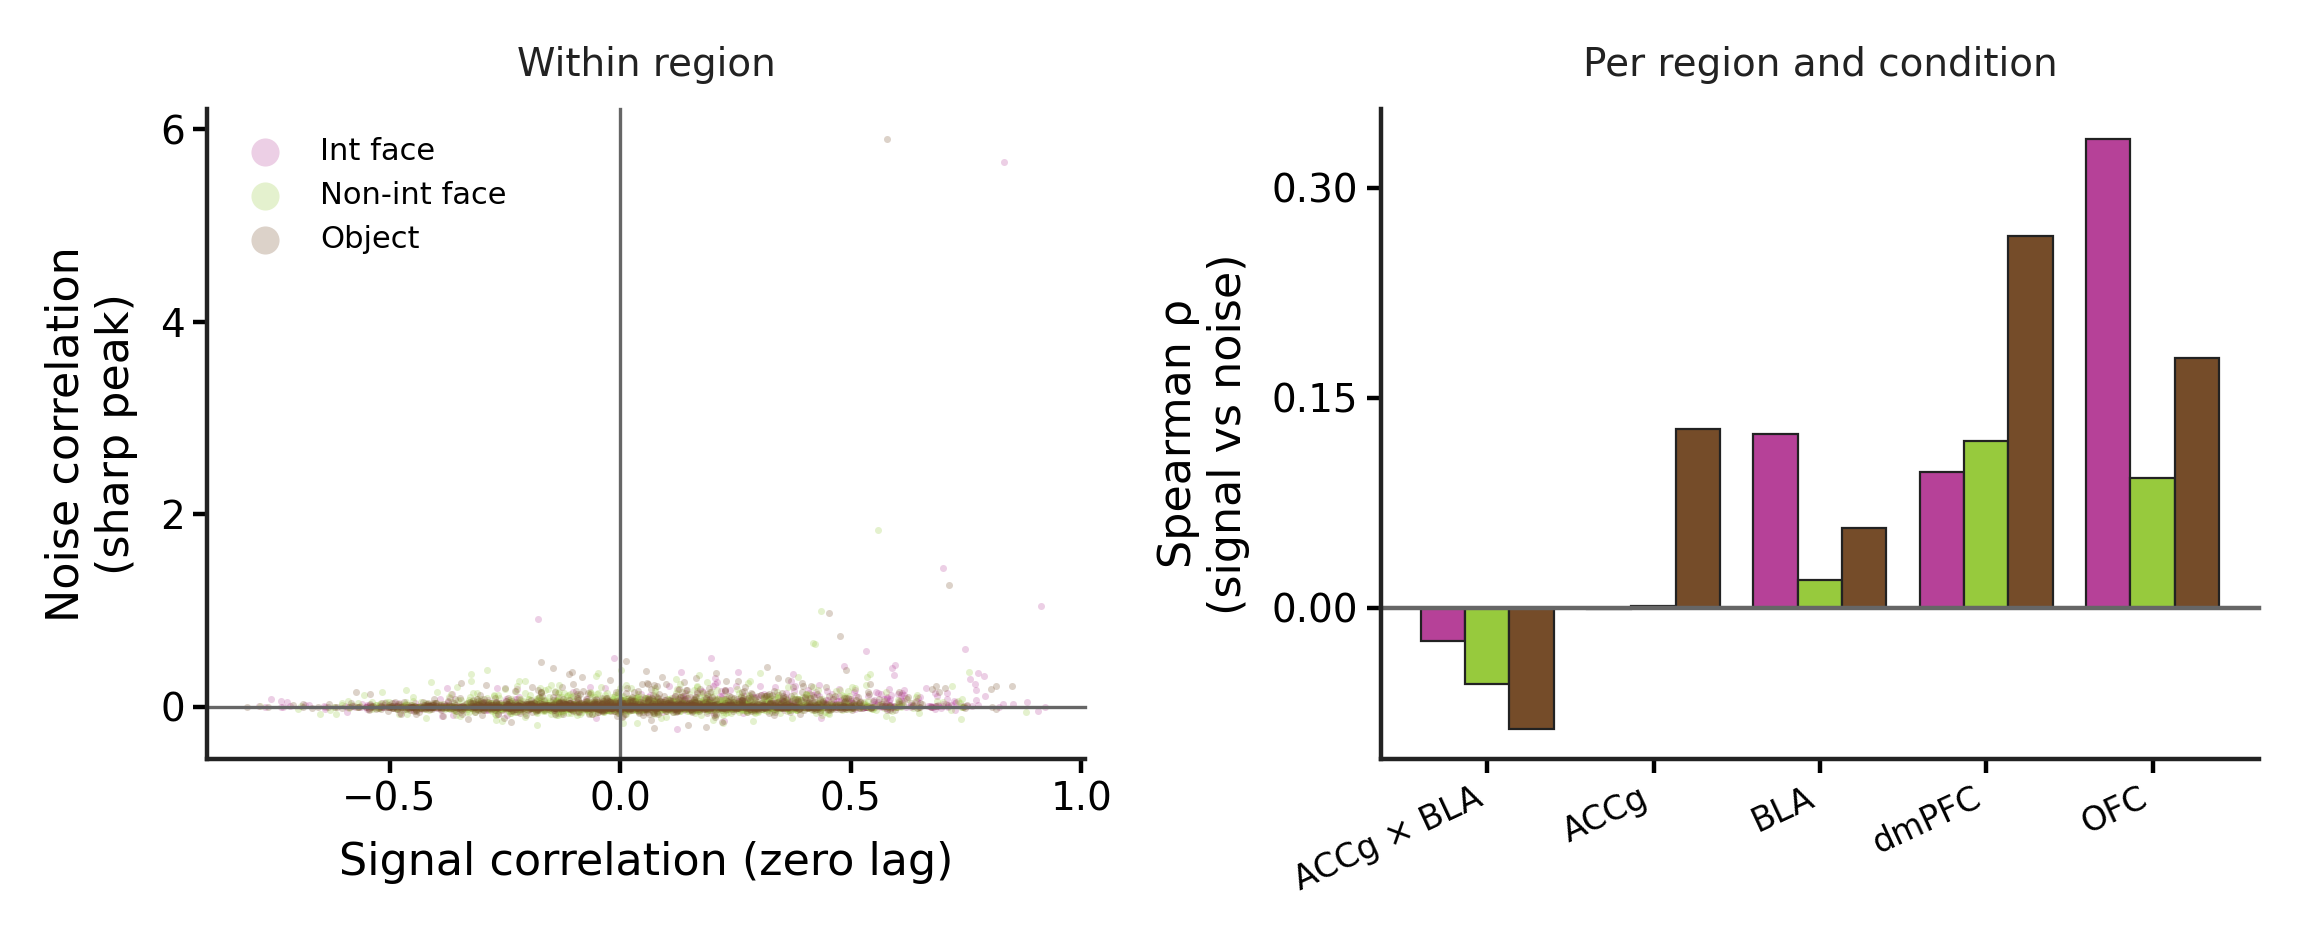

In [8]:
joined = sc.join_with_noise_correlation(signal, signal_settings)
correlations = sc.correlate_signal_with_noise(joined)
print(f"pairs with both measurements: {len(joined):,}")
display(correlations.round(4))

from dal_monte_2022_analysis.ephys.plotting import fixation_signal_correlation as sigviz
sig_figs = sigviz.SignalCorrelationPlotSettings(output_dir=FIGURE_DIR)
fig, paths = sigviz.plot_signal_vs_noise(joined, correlations, sig_figs,
                                         stem="fig06_signal_vs_noise")
display(Image(filename=str(paths["png"])))

## 7. The trial-count caveat, stated rather than used to dismiss

Interactive-face fixations outnumber the others about six to one, so
interactive-face mean timelines are estimated more precisely and correlate
better with anything. This inflates signal correlation for interactive face
specifically, and the cross-session null does not absorb it.

The noise-correlation results above are already trial-count matched, so they do
not carry this. The signal-correlation results are **not** matched — no matched
average exists — so the stratification below is the available control: shared
tuning predicts a difference flat across strata of the trial-count ratio,
estimation noise predicts one that grows with it.

This bounds how much of section 5 to believe. It does not make the analysis
worthless: the level of signal correlation over the cross-session null, the
region differences, and the signal/noise relationship in section 6 are all
comparisons that the imbalance does not obviously drive.

,ratio_stratum,n_pairs,median_trial_ratio,face_interactive,face_non_interactive,object,face_interactive_minus_object,p_value,effect_size_rank_biserial
0,"(0.96, 3.064]",1935,1.5590,0.2763,0.2735,0.2682,0.0080,0.2494,0.0160
1,"(3.064, 4.66]",699,4.1314,0.2991,0.2863,0.2902,0.0089,0.1385,0.0701
2,"(4.66, 8.833]",1581,7.2165,0.3315,0.2877,0.2582,0.0733,0.0000,0.2030
3,"(8.833, 16.164]",991,10.1053,0.2835,0.2709,0.2804,0.0031,0.7014,-0.0010


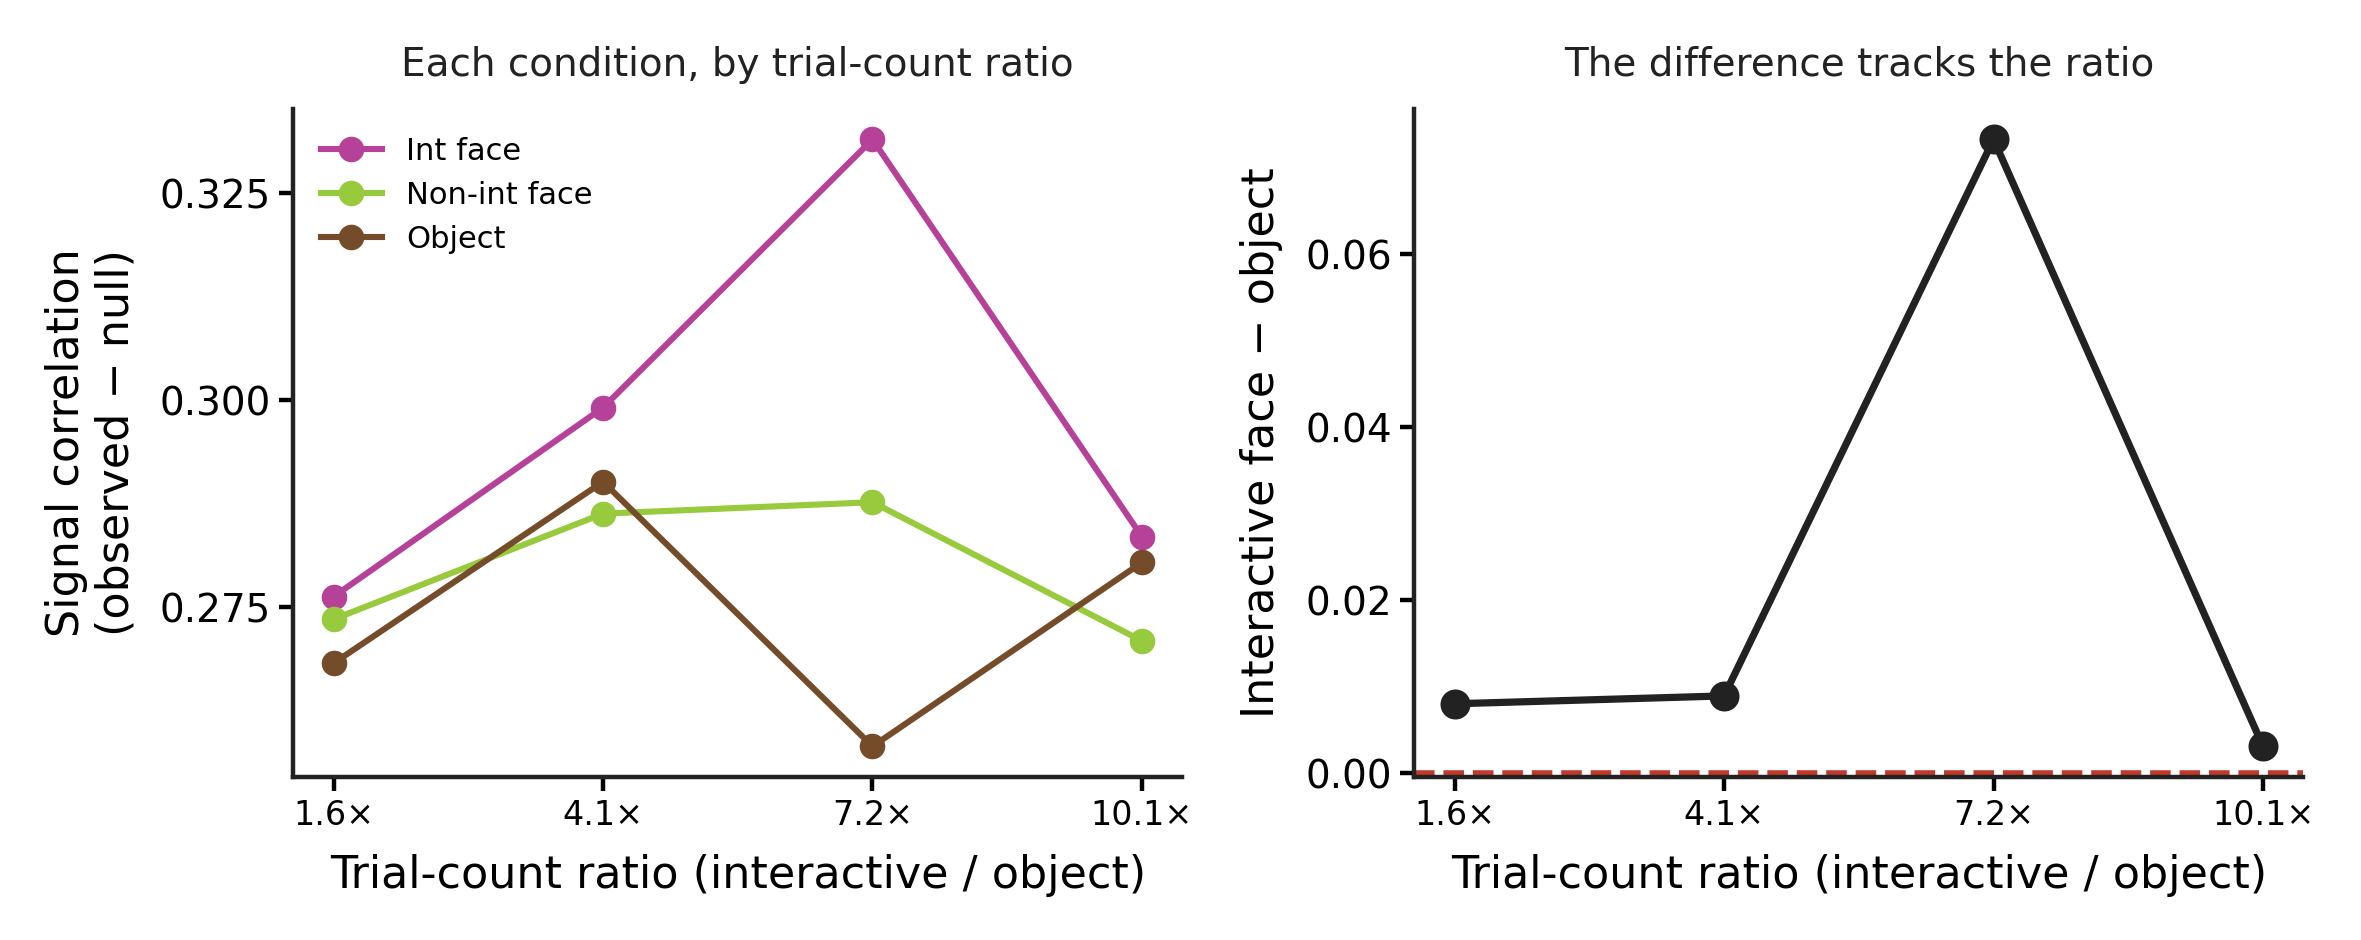

In [9]:
strata = sc.stratify_by_trial_ratio(signal, signal_settings, metric="peak_excess")
display(strata.round(4))

from dal_monte_2022_analysis.ephys.plotting import fixation_signal_correlation as sigviz
fig, paths = sigviz.plot_trial_count_confound(
    strata, sigviz.SignalCorrelationPlotSettings(output_dir=FIGURE_DIR),
    stem="fig07_trial_count_confound",
)
display(Image(filename=str(paths["png"])))

## What the two analyses say together

Fill in against the numbers, but the shape of the answer:

1. **Noise correlation is clearly above the circular-shift null in every
   region** — simultaneously recorded selective pairs do co-fire beyond what
   their individual rate profiles predict.
2. **Fixation type does not modulate it.** Effect sizes across every region and
   contrast are a few hundredths, and the significance is sample size.
3. **Signal correlation is above its own null**, and unlike noise correlation it
   does vary between regions and shows larger condition effect sizes — most of
   it in OFC, which is also where the trial-count confound bites hardest.
4. **The two are positively related within region.** Pairs whose mean responses
   resemble each other also tend to co-fire trial to trial.

The honest headline is that pairwise coupling in this dataset is a property of
the **pair and the region**, not of what the animal was looking at.